In [2]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [3]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
import os
print(os.listdir('/content'))

['.config', 'train.csv', 'sample_data']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/train.csv')

print("Shape (rows, columns):", df.shape)
display(df.head())

Shape (rows, columns): (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
print("--- Columns ki info ---")
df.info()

print("\n--- Missing values ---")
print(df.isnull().sum())

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

--- Columns ki info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null

In [7]:
# 1. Dates ko text se asli date type mein badalna (format dd/mm/yyyy)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# 2. Postal Code ki 11 missing values: sab Burlington, Vermont ki hain
print(df[df['Postal Code'].isnull()][['City', 'State']].drop_duplicates())
df['Postal Code'] = df['Postal Code'].fillna(5401)

# 3. Postal Code ko number se text banana (ye ek code hai, calculation ke liye nahi)
df['Postal Code'] = df['Postal Code'].astype(int).astype(str).str.zfill(5)

df[['Order Date', 'Ship Date', 'Postal Code']].info()

            City    State
2234  Burlington  Vermont
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order Date   9800 non-null   datetime64[ns]
 1   Ship Date    9800 non-null   datetime64[ns]
 2   Postal Code  9800 non-null   object        
dtypes: datetime64[ns](2), object(1)
memory usage: 229.8+ KB


In [8]:
# Order Date se saal aur mahina nikalna
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Delivery mein kitne din lage
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Country mein sirf ek value hai, is liye ye column kaam ka nahi
print("Country ki unique values:", df['Country'].unique())
df = df.drop(columns=['Country'])

display(df[['Order Date', 'Ship Date', 'Year', 'Month', 'Delivery Days']].head())
print(df['Delivery Days'].describe())

Country ki unique values: ['United States']


,Order Date,Ship Date,Year,Month,Delivery Days
0,2017-11-08,2017-11-11,2017,11,3
1,2017-11-08,2017-11-11,2017,11,3
2,2017-06-12,2017-06-16,2017,6,4
3,2016-10-11,2016-10-18,2016,10,7
4,2016-10-11,2016-10-18,2016,10,7


count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Delivery Days, dtype: float64


count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

Skewness: 12.983482865034619

Upper limit: 500.6405000000001
Outliers ki ginti: 1145


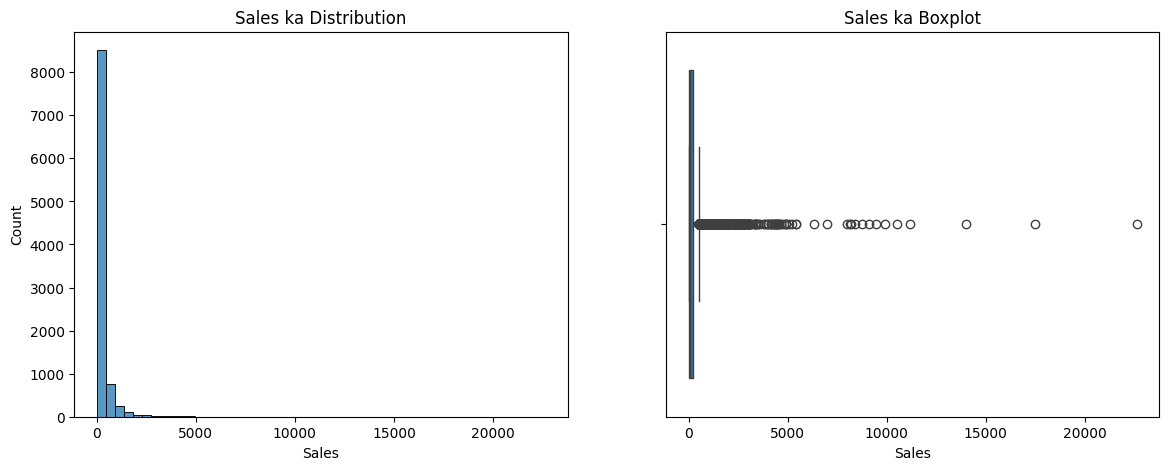

In [9]:
# 1. Sales ka summary
print(df['Sales'].describe())
print("\nSkewness:", df['Sales'].skew())

# 2. Outliers ka IQR method
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
outliers = df[df['Sales'] > upper_limit]
print("\nUpper limit:", upper_limit)
print("Outliers ki ginti:", len(outliers))

# 3. Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Sales'], bins=50, ax=axes[0])
axes[0].set_title('Sales ka Distribution')

sns.boxplot(x=df['Sales'], ax=axes[1])
axes[1].set_title('Sales ka Boxplot')

plt.show()

,Order Date,Customer Name,Category,Sub-Category,Product Name,Sales
2697,2015-03-18,Sean Miller,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480
6826,2017-10-02,Tamara Chand,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950
8153,2018-03-23,Raymond Buch,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960
2623,2018-10-22,Tom Ashbrook,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968
4190,2018-11-17,Hunter Lopez,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970
9039,2017-12-17,Adrian Barton,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740
4098,2015-09-23,Sanjit Chand,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950
4277,2017-04-16,Bill Shonely,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930
8488,2017-02-02,Sanjit Engle,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950
6425,2017-05-23,Christopher Conant,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976


Outliers ki rows ka %: 11.7
Outliers ka total sales mein hissa %: 64.3


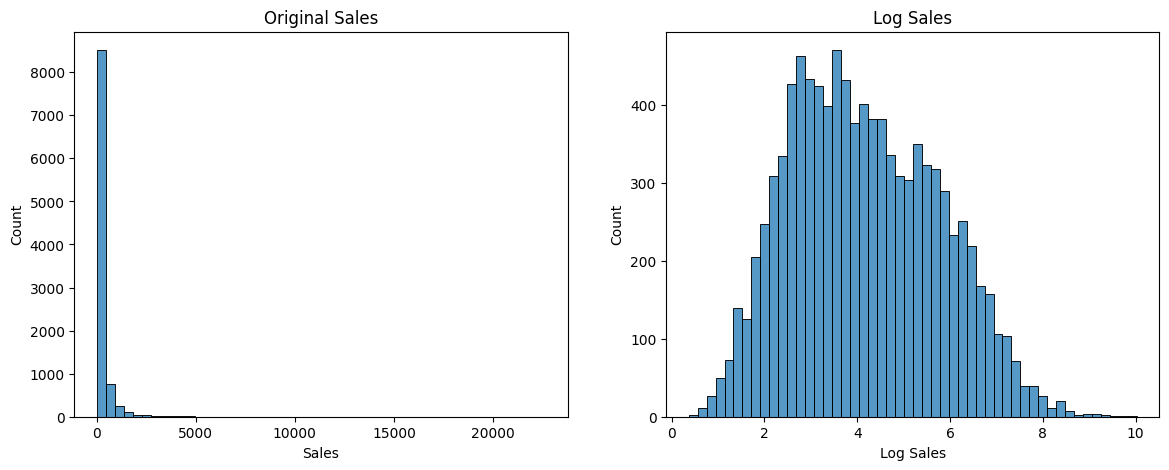

Skewness (original): 12.98
Skewness (log): 0.28


In [10]:
# 1. Sab se bari 10 sales kin cheezon ki hain
display(df.nlargest(10, 'Sales')[['Order Date', 'Customer Name', 'Category', 'Sub-Category', 'Product Name', 'Sales']])

# 2. Outliers poori sales ka kitna hissa hain
outlier_share = outliers['Sales'].sum() / df['Sales'].sum() * 100
print("Outliers ki rows ka %:", round(len(outliers) / len(df) * 100, 1))
print("Outliers ka total sales mein hissa %:", round(outlier_share, 1))

# 3. Log transform: bari values ko dabana taake shape saaf nazar aaye
df['Log Sales'] = np.log1p(df['Sales'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Sales'], bins=50, ax=axes[0])
axes[0].set_title('Original Sales')
sns.histplot(df['Log Sales'], bins=50, ax=axes[1])
axes[1].set_title('Log Sales')
plt.show()

print("Skewness (original):", round(df['Sales'].skew(), 2))
print("Skewness (log):", round(df['Log Sales'].skew(), 2))

Category
Technology         827456.0
Furniture          728659.0
Office Supplies    705422.0
Name: Sales, dtype: float64


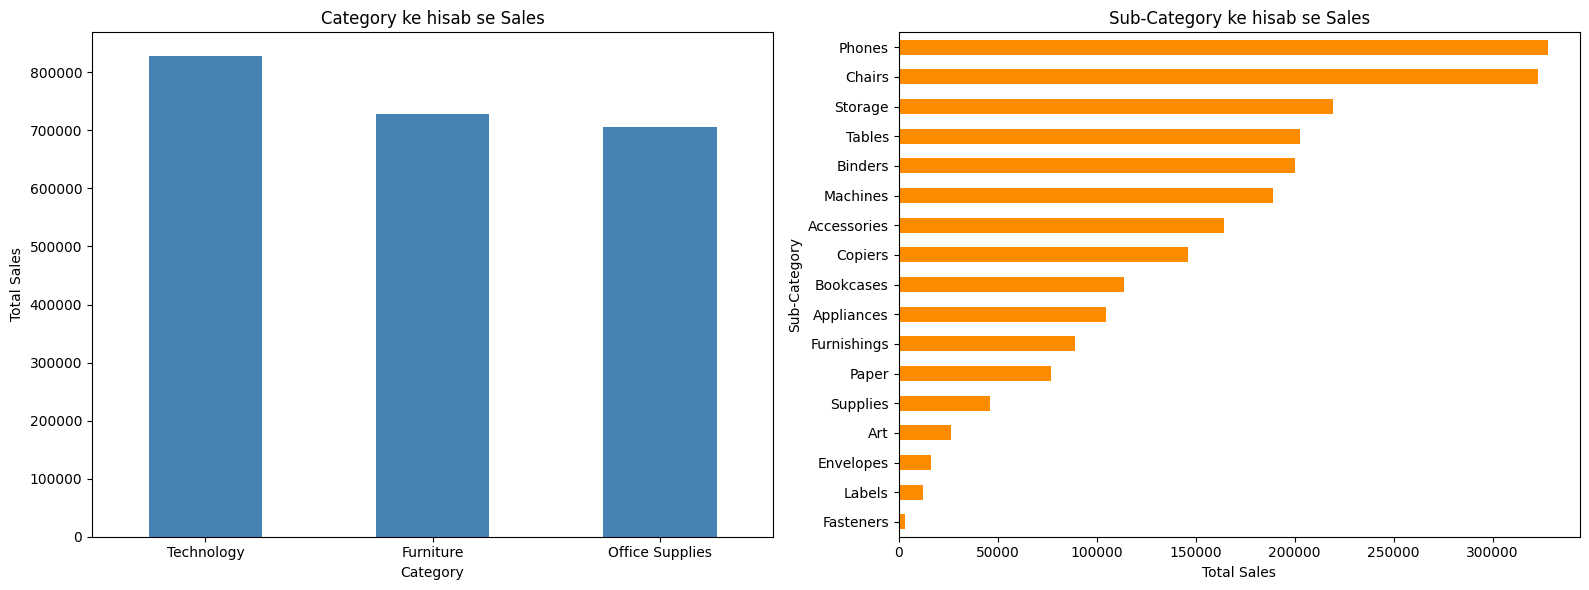

In [11]:
# 1. Category ke hisab se total sales
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_sales.round(0))

# 2. Sub-Category ke hisab se total sales
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

# 3. Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_sales.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Category ke hisab se Sales')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=0)

sub_sales.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Sub-Category ke hisab se Sales')
axes[1].set_xlabel('Total Sales')

plt.tight_layout()
plt.show()

Year
2015    479856.0
2016    459436.0
2017    600193.0
2018    722052.0
Name: Sales, dtype: float64

Growth % (pichle saal ke muqable):
Year
2015     NaN
2016    -4.3
2017    30.6
2018    20.3
Name: Sales, dtype: float64


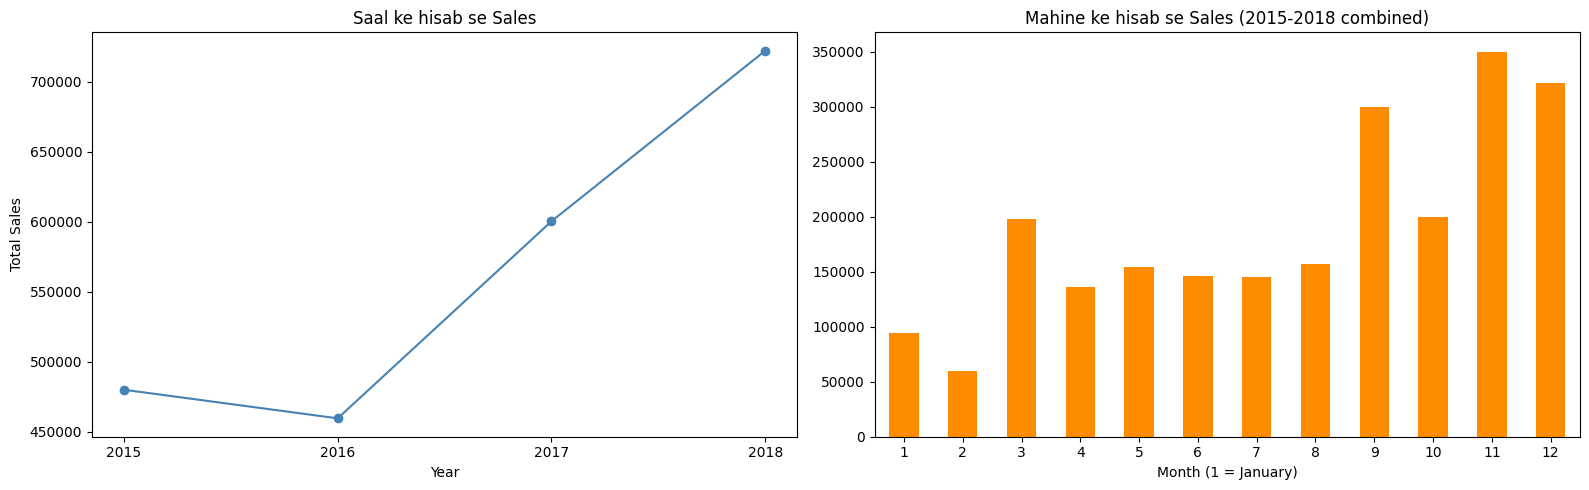

In [12]:
# 1. Saal ke hisab se total sales aur growth %
yearly = df.groupby('Year')['Sales'].sum()
print(yearly.round(0))
print("\nGrowth % (pichle saal ke muqable):")
print((yearly.pct_change() * 100).round(1))

# 2. Mahine ke hisab se total sales (saare saalon ko jama karke)
monthly = df.groupby('Month')['Sales'].sum()

# 3. Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

yearly.plot(kind='line', marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Saal ke hisab se Sales')
axes[0].set_xticks(yearly.index)
axes[0].set_ylabel('Total Sales')

monthly.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Mahine ke hisab se Sales (2015-2018 combined)')
axes[1].set_xlabel('Month (1 = January)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Year
2015    479856.0
2016    459436.0
2017    600193.0
2018    722052.0
Name: Sales, dtype: float64

Growth % (pichle saal ke muqable):
Year
2015     NaN
2016    -4.3
2017    30.6
2018    20.3
Name: Sales, dtype: float64


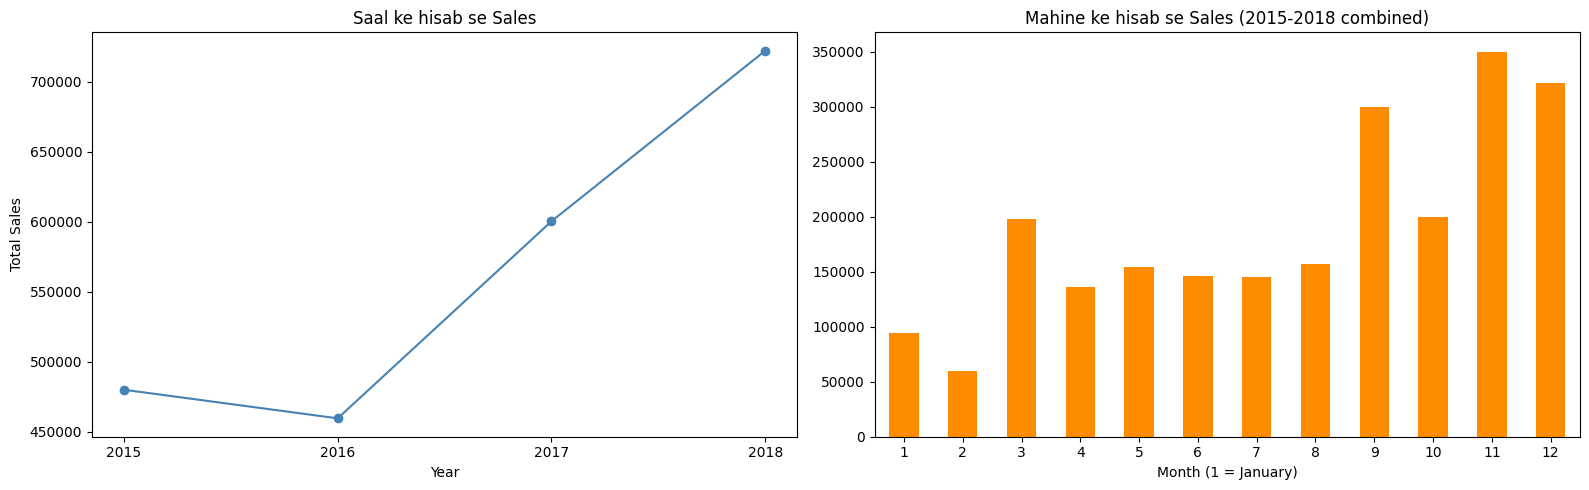

In [13]:
# 1. Saal ke hisab se total sales aur growth %
yearly = df.groupby('Year')['Sales'].sum()
print(yearly.round(0))
print("\nGrowth % (pichle saal ke muqable):")
print((yearly.pct_change() * 100).round(1))

# 2. Mahine ke hisab se total sales (saare saalon ko jama karke)
monthly = df.groupby('Month')['Sales'].sum()

# 3. Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

yearly.plot(kind='line', marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Saal ke hisab se Sales')
axes[0].set_xticks(yearly.index)
axes[0].set_ylabel('Total Sales')

monthly.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Mahine ke hisab se Sales (2015-2018 combined)')
axes[1].set_xlabel('Month (1 = January)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agar file nahi hai to upload ka button aayega
if not os.path.exists('/content/train.csv'):
    from google.colab import files
    files.upload()

# Load
df = pd.read_csv('/content/train.csv')

# Dates ko asli date banana
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Postal Code theek karna
df['Postal Code'] = df['Postal Code'].fillna(5401)
df['Postal Code'] = df['Postal Code'].astype(int).astype(str).str.zfill(5)

# Nayi columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Log Sales'] = np.log1p(df['Sales'])

# Country hatana
df = df.drop(columns=['Country'])

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Shape: (9800, 21)
Missing values: 0


Region
West       710220.0
East       669519.0
Central    492647.0
South      389151.0
Name: Sales, dtype: float64

Top 5 states ka hissa %: 51.9


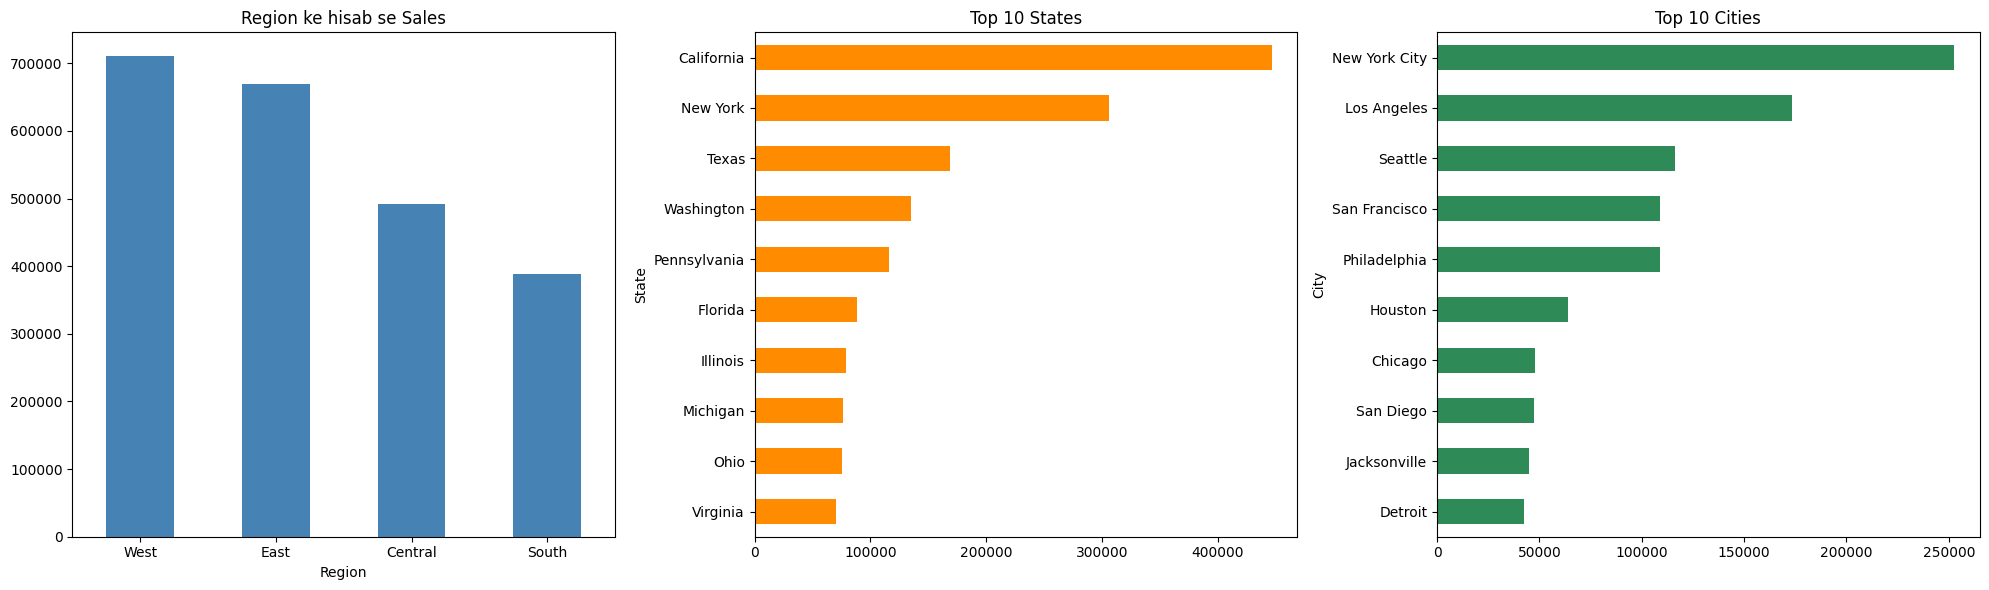

In [15]:
# 1. Region ke hisab se sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales.round(0))

# 2. Top 10 States aur Top 10 Cities
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)

# Top 5 states ka total sales mein hissa
top5_share = state_sales.head(5).sum() / state_sales.sum() * 100
print("\nTop 5 states ka hissa %:", round(top5_share, 1))

# 3. Charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

region_sales.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Region ke hisab se Sales')
axes[0].tick_params(axis='x', rotation=0)

state_sales.head(10).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 States')

city_sales.head(10).sort_values().plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Top 10 Cities')

plt.tight_layout()
plt.show()

             Total_Sales  Rows  Avg_Sale  Customers
Segment                                            
Consumer       1148060.5  5101     225.1        409
Corporate       688494.1  2953     233.2        236
Home Office     424982.2  1746     243.4        148

                 Rows  Total_Sales  Avg_Delivery_Days
Ship Mode                                           
First Class     1501    345572.26               2.18
Same Day         538    125219.04               0.04
Second Class    1902    449914.18               3.25
Standard Class  5859   1340831.31               5.01


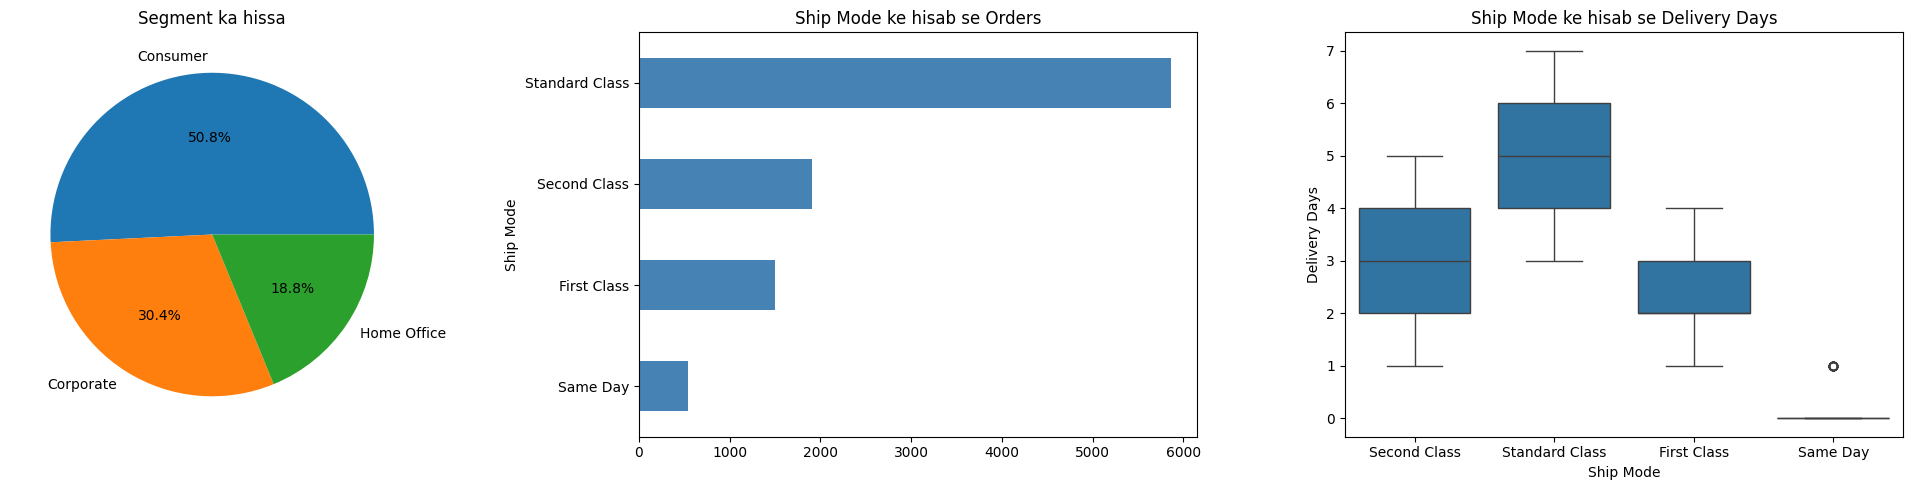

In [16]:
# 1. Segment ke hisab se: total sales, orders ki ginti, average sale, customers
segment = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Rows=('Sales', 'count'),
    Avg_Sale=('Sales', 'mean'),
    Customers=('Customer ID', 'nunique')
).round(1)
print(segment)

# 2. Ship Mode ke hisab se: rows, total sales, average delivery days
ship = df.groupby('Ship Mode').agg(
    Rows=('Sales', 'count'),
    Total_Sales=('Sales', 'sum'),
    Avg_Delivery_Days=('Delivery Days', 'mean')
).round(2)
print("\n", ship)

# 3. Charts
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

segment['Total_Sales'].plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Segment ka hissa')
axes[0].set_ylabel('')

ship['Rows'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Ship Mode ke hisab se Orders')

sns.boxplot(data=df, x='Ship Mode', y='Delivery Days', ax=axes[2])
axes[2].set_title('Ship Mode ke hisab se Delivery Days')

plt.tight_layout()
plt.show()

Customer ID  Customer Name     
SM-20320     Sean Miller           25043.0
TC-20980     Tamara Chand          19052.0
RB-19360     Raymond Buch          15117.0
TA-21385     Tom Ashbrook          14596.0
AB-10105     Adrian Barton         14474.0
KL-16645     Ken Lonsdale          14175.0
SC-20095     Sanjit Chand          14142.0
HL-15040     Hunter Lopez          12873.0
SE-20110     Sanjit Engle          12209.0
CC-12370     Christopher Conant    12129.0
Name: Sales, dtype: float64

Kul customers: 793
Top 10 ka hissa %: 6.8

            Customers   Revenue
RFM_Group                     
Champions        201  944678.0
Loyal            212  771826.0
Potential        183  361099.0
At Risk          140  156604.0
Lost              57   27330.0


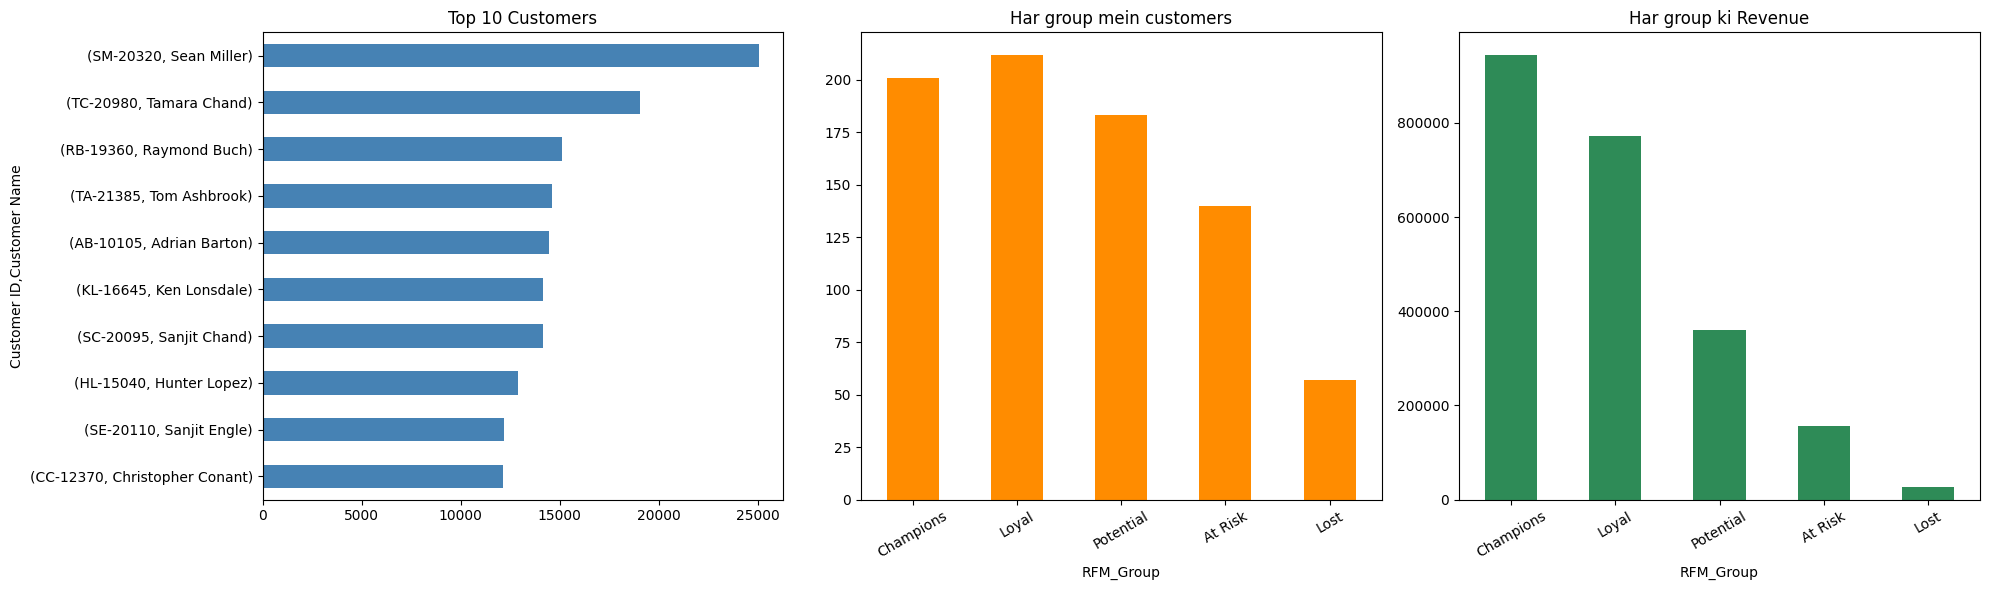

In [17]:
# 1. Top 10 customers
customer_sales = df.groupby(['Customer ID', 'Customer Name'])['Sales'].sum().sort_values(ascending=False)
print(customer_sales.head(10).round(0))
print("\nKul customers:", df['Customer ID'].nunique())
print("Top 10 ka hissa %:", round(customer_sales.head(10).sum() / customer_sales.sum() * 100, 1))

# 2. RFM table
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
)

# 3. Har cheez ko 1 se 4 ka score dena (4 = behtar)
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm['Score'] = rfm['R'] + rfm['F'] + rfm['M']

# 4. Score se group banana
def rfm_group(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['RFM_Group'] = rfm['Score'].apply(rfm_group)

summary = rfm.groupby('RFM_Group').agg(
    Customers=('Monetary', 'count'),
    Revenue=('Monetary', 'sum')
).sort_values('Revenue', ascending=False).round(0)
print("\n", summary)

# 5. Charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

customer_sales.head(10).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Customers')

summary['Customers'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Har group mein customers')
axes[1].tick_params(axis='x', rotation=30)

summary['Revenue'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Har group ki Revenue')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Mahine: 48
Test MAPE %: 19.8
Test MAE: 10545.0

2019 ka forecast:
2019-01-01     49393.0
2019-02-01     41600.0
2019-03-01     71943.0
2019-04-01     60876.0
2019-05-01     68134.0
2019-06-01     62708.0
2019-07-01     66241.0
2019-08-01     65234.0
2019-09-01    105703.0
2019-10-01     76598.0
2019-11-01    114262.0
2019-12-01    116353.0
Freq: MS, dtype: float64
2018 total: 722052.0
2019 forecast total: 899044.0


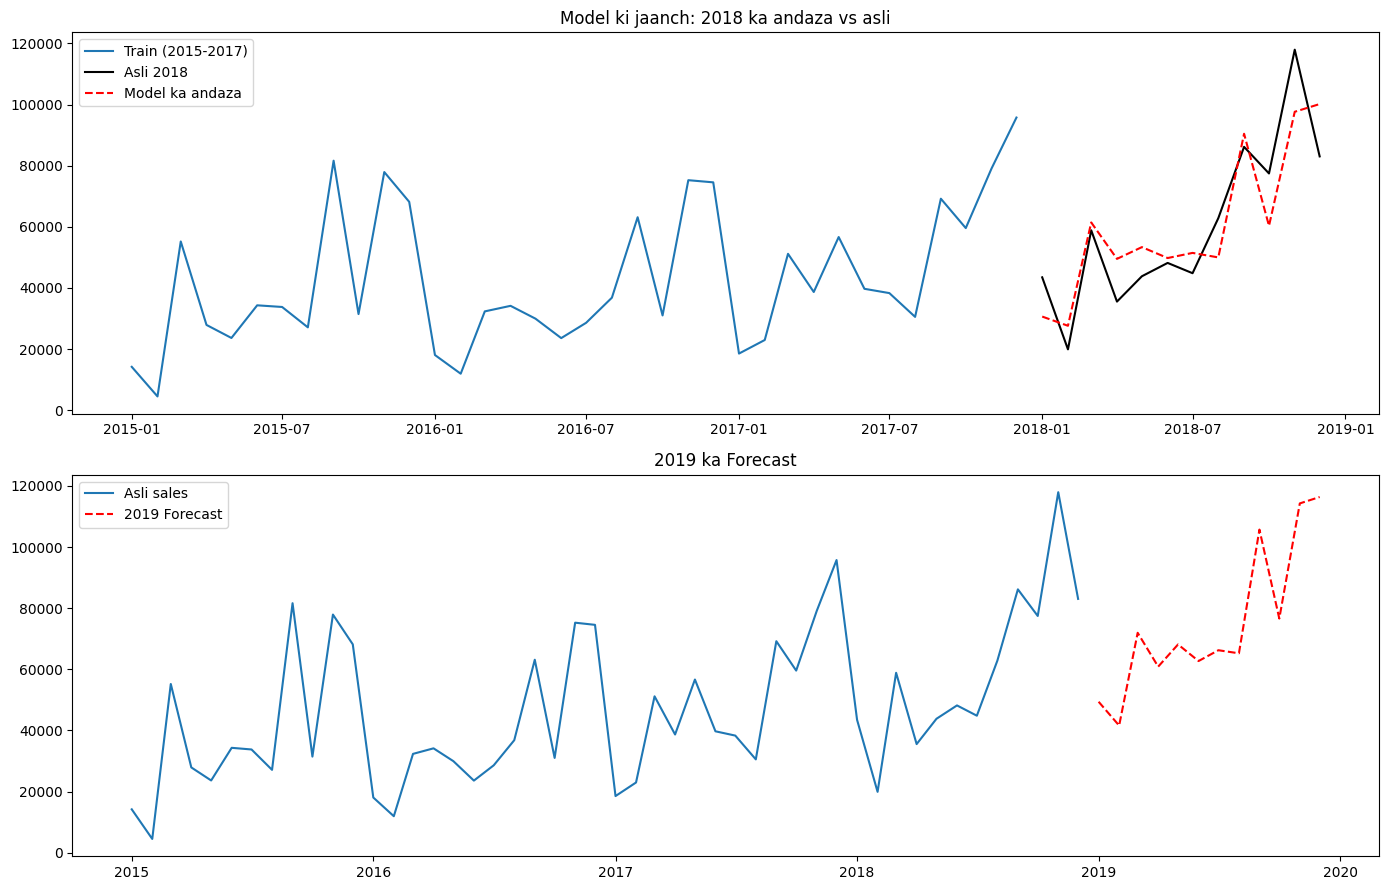

In [18]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Monthly sales ki series
monthly_sales = df.set_index('Order Date')['Sales'].resample('MS').sum()
print("Mahine:", len(monthly_sales))

# 2. Train aur test: 2015-2017 se seekho, 2018 par test karo
train = monthly_sales[:'2017-12-01']
test = monthly_sales['2018-01-01':]

model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
test_pred = model.forecast(12)

mape = (abs(test - test_pred) / test).mean() * 100
mae = abs(test - test_pred).mean()
print("Test MAPE %:", round(mape, 1))
print("Test MAE:", round(mae, 0))

# 3. Poore data par train karke 2019 ka forecast
final_model = ExponentialSmoothing(monthly_sales, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_2019 = final_model.forecast(12)
print("\n2019 ka forecast:")
print(forecast_2019.round(0))
print("2018 total:", round(monthly_sales['2018'].sum(), 0))
print("2019 forecast total:", round(forecast_2019.sum(), 0))

# 4. Charts
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(train.index, train, label='Train (2015-2017)')
axes[0].plot(test.index, test, label='Asli 2018', color='black')
axes[0].plot(test.index, test_pred, label='Model ka andaza', color='red', linestyle='--')
axes[0].set_title('Model ki jaanch: 2018 ka andaza vs asli')
axes[0].legend()

axes[1].plot(monthly_sales.index, monthly_sales, label='Asli sales')
axes[1].plot(forecast_2019.index, forecast_2019, label='2019 Forecast', color='red', linestyle='--')
axes[1].set_title('2019 ka Forecast')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agar file nahi hai to upload ka button aayega
if not os.path.exists('/content/train.csv'):
    from google.colab import files
    files.upload()

df = pd.read_csv('/content/train.csv')

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df['Postal Code'] = df['Postal Code'].fillna(5401)
df['Postal Code'] = df['Postal Code'].astype(int).astype(str).str.zfill(5)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Log Sales'] = np.log1p(df['Sales'])

df = df.drop(columns=['Country'])

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Shape: (9800, 21)
Missing values: 0


Mahine: 48
Test MAPE %: 19.8
Test MAE: 10545.0

2019 ka forecast:
2019-01-01     49393.0
2019-02-01     41600.0
2019-03-01     71943.0
2019-04-01     60876.0
2019-05-01     68134.0
2019-06-01     62708.0
2019-07-01     66241.0
2019-08-01     65234.0
2019-09-01    105703.0
2019-10-01     76598.0
2019-11-01    114262.0
2019-12-01    116353.0
Freq: MS, dtype: float64
2018 total: 722052.0
2019 forecast total: 899044.0


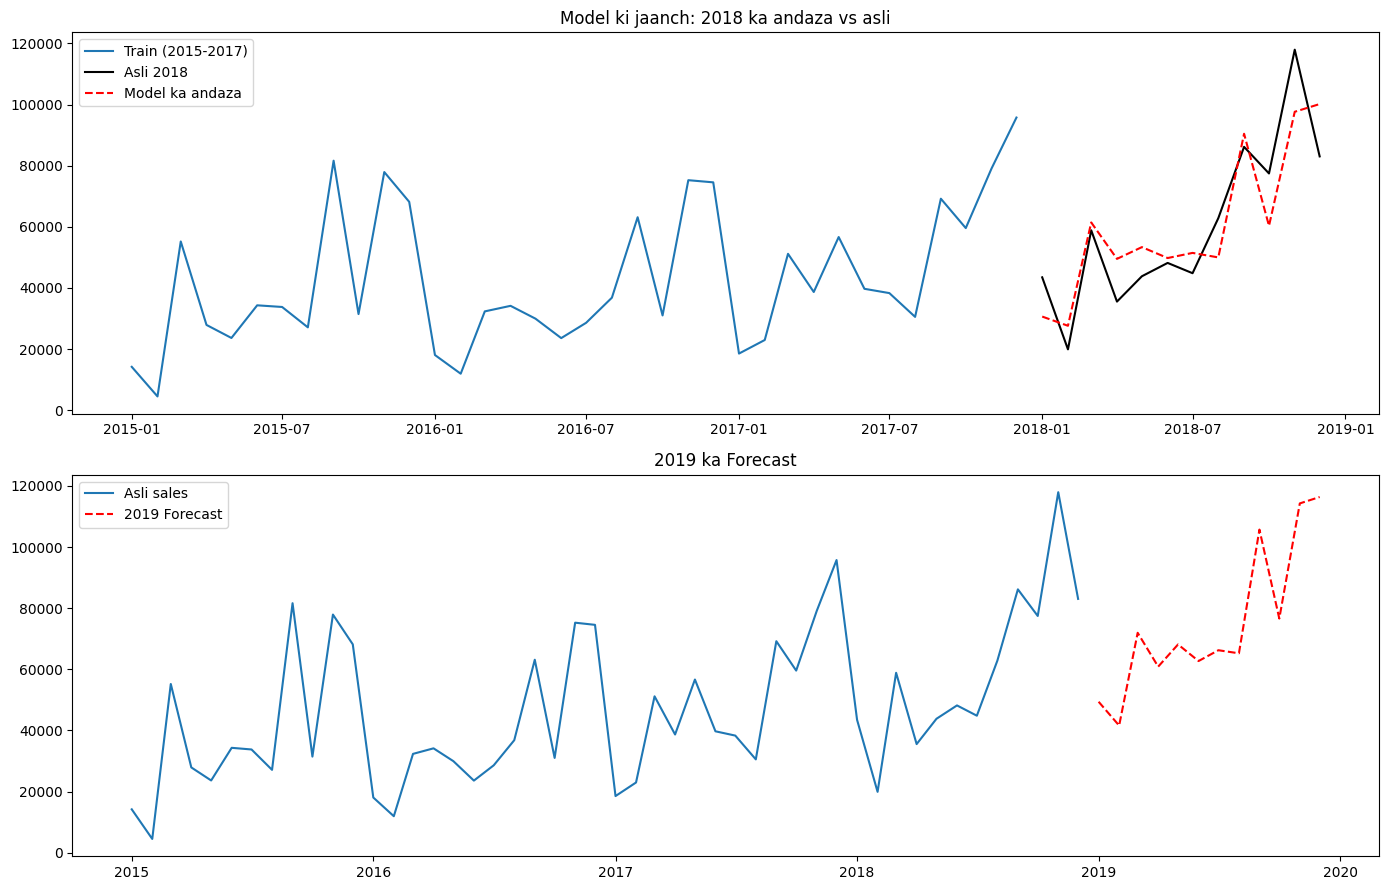

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Monthly sales ki series
monthly_sales = df.set_index('Order Date')['Sales'].resample('MS').sum()
print("Mahine:", len(monthly_sales))

# 2. Train aur test: 2015-2017 se seekho, 2018 par test karo
train = monthly_sales[:'2017-12-01']
test = monthly_sales['2018-01-01':]

model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
test_pred = model.forecast(12)

mape = (abs(test - test_pred) / test).mean() * 100
mae = abs(test - test_pred).mean()
print("Test MAPE %:", round(mape, 1))
print("Test MAE:", round(mae, 0))

# 3. Poore data par train karke 2019 ka forecast
final_model = ExponentialSmoothing(monthly_sales, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_2019 = final_model.forecast(12)
print("\n2019 ka forecast:")
print(forecast_2019.round(0))
print("2018 total:", round(monthly_sales['2018'].sum(), 0))
print("2019 forecast total:", round(forecast_2019.sum(), 0))

# 4. Charts
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(train.index, train, label='Train (2015-2017)')
axes[0].plot(test.index, test, label='Asli 2018', color='black')
axes[0].plot(test.index, test_pred, label='Model ka andaza', color='red', linestyle='--')
axes[0].set_title('Model ki jaanch: 2018 ka andaza vs asli')
axes[0].legend()

axes[1].plot(monthly_sales.index, monthly_sales, label='Asli sales')
axes[1].plot(forecast_2019.index, forecast_2019, label='2019 Forecast', color='red', linestyle='--')
axes[1].set_title('2019 ka Forecast')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
from google.colab import files

# 1. Key numbers
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

print("Total Sales:", round(total_sales, 0))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(total_sales / total_orders, 1))
print("Data ki range:", df['Order Date'].min().date(), "se", df['Order Date'].max().date())

# 2. Saal ke hisab se sales
print("\nSaal ke hisab se Sales:")
print(df.groupby('Year')['Sales'].sum().round(0))

# 3. Category ke hisab se sales
print("\nCategory ke hisab se Sales:")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False).round(0))

# 4. Cleaned data save karna
df.to_csv('/content/superstore_cleaned.csv', index=False)
files.download('/content/superstore_cleaned.csv')

# 5. RFM table (sirf agar Step 13 isi session mein chala ho)
if 'rfm' in globals():
    rfm.to_csv('/content/customer_rfm.csv')
    files.download('/content/customer_rfm.csv')
else:
    print("\nrfm nahi mila, Step 13 ka cell chalayein to ye file bhi ban jayegi.")

Total Sales: 2261537.0
Total Orders: 4922
Total Customers: 793
Average Order Value: 459.5
Data ki range: 2015-01-03 se 2018-12-30

Saal ke hisab se Sales:
Year
2015    479856.0
2016    459436.0
2017    600193.0
2018    722052.0
Name: Sales, dtype: float64

Category ke hisab se Sales:
Category
Technology         827456.0
Furniture          728659.0
Office Supplies    705422.0
Name: Sales, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from google.colab import files
rfm.to_csv('/content/customer_rfm.csv')
files.download('/content/customer_rfm.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>